# **Project Title:** Thematic Energy Fund Returns Forecasting

# **Group  40**



##Overview

This project aimed to **analyze and predict the daily returns** of selected Indian energy-sector mutual funds and Exchange-Traded Funds (ETFs) over a two-year period (November 2023 to November 2025). The approach combined three primary datasets: **Daily Net Asset Value (NAV)** data from AMFI, **Holdings data** for structural analysis, and relevant **Macroeconomic Data** (including Brent Crude, WTI Crude, Natural Gas, Nifty 50, and Sensex) sourced from Yahoo Finance. A key phase was **Feature Engineering**, where raw data was transformed by calculating **returns, volatility, rolling statistics** (like 7-day and 30-day moving averages), **lag features**, and **interaction terms** between the target fund and macroeconomic variables (e.g., crude oil and USD/INR). The final set of 17 high-quality features was selected using a hybrid approach combining **Recursive Feature Elimination (RFE)** and **Random Forest Feature Importance**. Four regression models were trained on the data: Linear Regression, Ridge Regression, Lasso Regression, and Random Forest. The main findings indicate that **Ridge Regression** yielded the most accurate predictions, achieving the highest R-squared value (0.6847), lowest Mean Absolute Error (MAE: 0.0033), and lowest Root Mean Squared Error (RMSE: 0.0043) on the test set, demonstrating moderate predictive power over short-term fund

In [46]:
#how to run :
# first you have to upload the given dataset in the zip file included and then run all the codes for that file

import pandas as pd
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [47]:
!pip install yfinance pandas
!pip install -q openpyxl


In [48]:
pip install yfinance pandas requests openpyxl


In [49]:
pip install xgboost

#Data Collection

NAV data has been collected from AMFI website. Now, we clean the individual NAV files and combine them into a single nav_data file.

The data for this study was collected from multiple reliable and publicly available financial sources.  
Three main datasets were required: **NAV Data**, **Holdings Data**, and **Macroeconomic Data**.



### (a) NAV Data

- Daily Net Asset Value (NAV) data was downloaded from the official **AMFI (Association of Mutual Funds in India)** website.
- For each scheme, the **Direct Growth Plan** NAV history was downloaded.
- The time period considered was **15 November 2023 to 15 November 2025**, providing adequate coverage for short-term performance analysis.
- All NAV files were merged into a single dataset, standardised, and sorted by date.










### (b) Holdings Data

- Holdings were collected from each fund’s most recent **monthly factsheet**, published by their respective **Asset Management Companies (AMCs)**.
- Additional verification was done using sources such as **Morningstar India** and **Value Research Online**.
- For each scheme, the following fields were recorded:  
  - **Company Name**  
  - **Sector / Industry**  
  - **Weight (%)**





### (c) Macroeconomic Data

- Macroeconomic indicators relevant to the energy sector were collected using **Yahoo Finance** via Python’s `yfinance` library.
- The following variables were included:
  - Brent Crude Oil Price (`BZ=F`)
  - WTI Crude Oil Price (`CL=F`)
  - Natural Gas Price (`NG=F`)
  - NIFTY 50 Index (`^NSEI`)
  - NIFTY Energy Index (`^CNXENERGY`)
  - S&P BSE Sensex (`^BSESN`)
  - USD/INR Exchange Rate (`USDINR=X`)
- Macro data was aligned to NAV dates using **forward-filling** to adjust for non-trading days.

In [50]:
# Macro Tickers (Yahoo Finance)

tickers = {
    "Brent_Crude": "BZ=F",
    "WTI_Crude": "CL=F",
    "Natural_Gas": "NG=F",
    "Nifty_50": "^NSEI",
    "Nifty_Energy": "^CNXENERGY",
    "Sensex": "^BSESN",
    "USDINR": "USDINR=X"
}

# Download + Combine Macro Data

macro_df = pd.DataFrame()

for name, symbol in tickers.items():
    print(f"Downloading: {name} ({symbol})")

    data = yf.download(symbol,
                       start="2023-11-15",
                       end="2025-11-15",
                       progress=False)

    series = data["Close"][symbol].rename(name)

    macro_df = pd.concat([macro_df, series], axis=1)

# Clean final dataset
macro_df.index.name = "Date"
macro_df = macro_df.dropna()

macro_df.reset_index(inplace=True)
macro_df["Date"] = macro_df["Date"].dt.strftime("%Y-%m-%d")
macro_df.to_excel("macro_data.xlsx", index=False)

macro_df.head()

Downloading: Brent_Crude (BZ=F)
Downloading: WTI_Crude (CL=F)
Downloading: Natural_Gas (NG=F)
Downloading: Nifty_50 (^NSEI)


/tmp/ipython-input-3176801447.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol,
/tmp/ipython-input-3176801447.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol,
/tmp/ipython-input-3176801447.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol,
/tmp/ipython-input-3176801447.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol,


Downloading: Nifty_Energy (^CNXENERGY)
Downloading: Sensex (^BSESN)
Downloading: USDINR (USDINR=X)


/tmp/ipython-input-3176801447.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol,
/tmp/ipython-input-3176801447.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol,
/tmp/ipython-input-3176801447.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol,


,Date,Brent_Crude,WTI_Crude,Natural_Gas,Nifty_50,Nifty_Energy,Sensex,USDINR
0,2023-11-15,81.180000,76.660004,3.190,19675.449219,28352.500000,65675.929688,82.981598
1,2023-11-16,77.419998,72.900002,3.062,19765.199219,28447.800781,65982.476562,83.186203
2,2023-11-17,80.610001,75.889999,2.960,19731.800781,28312.650391,65794.726562,83.120300
3,2023-11-20,82.320000,77.599998,2.882,19694.000000,28287.199219,65655.148438,83.291496
4,2023-11-21,82.449997,77.769997,2.846,19783.400391,28356.250000,65930.773438,83.322197


Merging nav_data with macro_data

In [51]:
excel_file = "Group40_Data.xlsx"
nav = pd.read_excel(excel_file, sheet_name="nav_data")
macro = pd.read_excel(excel_file, sheet_name="macro_data")


nav = nav.rename(columns=lambda c: c.strip())
macro = macro.rename(columns=lambda c: c.strip())


nav["Date"] = pd.to_datetime(nav["Date"], errors="coerce")
macro["Date"] = pd.to_datetime(macro["Date"], errors="coerce")

nav = nav.dropna(subset=["Date"]).sort_values("Date")
macro = macro.dropna(subset=["Date"]).sort_values("Date")


macro = macro.set_index("Date")
nav_dates = pd.DataFrame({"Date": sorted(nav["Date"].unique())}).set_index("Date")

macro_aligned = macro.reindex(nav_dates.index)
macro_aligned = macro_aligned.ffill().bfill().reset_index()


long_nav = nav[["Date", "Fund Name", "NAV"]].copy()
nav_wide = long_nav.pivot(index="Date", columns="Fund Name", values="NAV").reset_index()


merged_wide = pd.merge(nav_wide, macro_aligned, on="Date", how="left")
merged_long = pd.merge(long_nav, macro_aligned, on="Date", how="left")
merged_wide["Date"] = merged_wide["Date"].dt.strftime("%Y-%m-%d")
merged_long["Date"] = merged_long["Date"].dt.strftime("%Y-%m-%d")

with pd.ExcelWriter("final_merged.xlsx") as writer:
    merged_wide.to_excel(writer, sheet_name="merged_wide", index=False)
    merged_long.to_excel(writer, sheet_name="merged_long", index=False)

print("Done. File saved: final_merged.xlsx")


Done. File saved: final_merged.xlsx


All collected files were cleaned, standardised, and consolidated into two main datasets:  
- **Merged Wide** (date-wise combined dataset)  
- **Merged Long** (fund-wise dataset)  

These datasets form the basis of the exploratory analysis.

#Data Cleaning

In [52]:
FILEPATH = "Group40_Data.xlsx"
xl = pd.ExcelFile(FILEPATH)
print("Detected sheets:", xl.sheet_names)


dfs = {name: xl.parse(name) for name in xl.sheet_names}


Detected sheets: ['fund_metadata', 'nav_data', 'holdings', 'macro_data', 'merged_wide', 'merged_long', 'clean_wide']


##Sheet summary (shape, duplicates, top missing columns)

In [53]:
for name, df in dfs.items():
    print(f"\n--- {name} ---")
    print("Shape:", df.shape)
    print("Duplicate rows:", df.duplicated().sum())
    miss = df.isna().sum().sort_values(ascending=False)
    print("Total missing:", int(miss.sum()))
    if miss.sum() > 0:
        print("Top missing columns:", miss[miss>0].head(8).to_dict())
    display(df.head(3))



--- fund_metadata ---
Shape: (7, 11)
Duplicate rows: 0
Total missing: 0


,Fund Name,AMC,SEBI Category,Fund Type,Benchmark,Launch Date,AUM (Cr),Expense Ratio (%),Risk Level,Fund Manager,Investment Objective
0,ICICI Prudential Commodities Fund,ICICI Prudential Commodities Fund,Sectoral/Thematic - Commodities (Energy focused),Active,Internal Benchmark / Nifty Commodities TRI,2024-10-15,3188.69,2.1,High,TBD,Invests in energy-related commodities and comp...
1,Aditya Birla Sun Life ESG Integration Strategy...,Aditya Birla Sun Life MF,Sectoral/Thematic - Energy,Active,S&P BSE Energy TRI,2020-12-24,616.69,1.9,Very High,TBD,Capital appreciation by investing in energy se...
2,DSP Natural Resources and New Energy Fund,DSP Mutual Fund,Sectoral/Thematic - Natural Resources & New En...,Active,S&P Global Natural Resources Index,2008-04-25,1474.17,2.3,High,TBD,Invest in natural resources and renewable ener...



--- nav_data ---
Shape: (16139, 3)
Duplicate rows: 0
Total missing: 0


,Date,Fund Name,NAV
0,2020-12-29,Aditya Birla Sun Life ESG Integration Strategy...,10.02
1,2020-12-30,Aditya Birla Sun Life ESG Integration Strategy...,10.04
2,2020-12-31,Aditya Birla Sun Life ESG Integration Strategy...,10.05



--- holdings ---
Shape: (71, 4)
Duplicate rows: 0
Total missing: 63
Top missing columns: {'Holdings (As of 31st October 2025)': 63}


...

,Date,Aditya Birla Sun Life ESG Integration Strategy Fund,DSP Natural Resources and New Energy Fund,ICICI Prudential Commodities Fund,Invesco India PSU Fund,Nippon India ETF Nifty 50 BeES,Nippon India Power & Infra Fund,Tata Resources & Energy Fund,Brent_Crude,WTI_Crude,Natural_Gas,Nifty_50,Nifty_Energy,Sensex,USDINR
0,2013-11-19,NaN,11.772,NaN,8.47,NaN,46.4893,NaN,106.919998,93.339996,3.556,6203.350098,7836.799805,20890.820312,62.200001
1,2013-11-20,NaN,11.773,NaN,8.40,NaN,46.3259,NaN,108.059998,93.330002,3.674,6122.899902,7746.000000,20635.130859,62.110001
2,2013-11-21,NaN,11.611,NaN,8.26,NaN,45.4953,NaN,110.080002,95.440002,3.702,5999.049805,7606.299805,20229.050781,62.759998



--- merged_long ---
Shape: (16139, 10)
Duplicate rows: 0
Total missing: 0


,Date,Fund Name,NAV,Brent_Crude,WTI_Crude,Natural_Gas,Nifty_50,Nifty_Energy,Sensex,USDINR
0,2013-11-19,DSP Natural Resources and New Energy Fund,11.7720,106.919998,93.339996,3.556,6203.350098,7836.799805,20890.820312,62.200001
1,2013-11-19,Nippon India Power & Infra Fund,46.4893,106.919998,93.339996,3.556,6203.350098,7836.799805,20890.820312,62.200001
2,2013-11-19,Invesco India PSU Fund,8.4700,106.919998,93.339996,3.556,6203.350098,7836.799805,20890.820312,62.200001



--- clean_wide ---
Shape: (2955, 15)
Duplicate rows: 0
Total missing: 0


,Date,Aditya Birla Sun Life ESG Integration Strategy Fund,DSP Natural Resources and New Energy Fund,ICICI Prudential Commodities Fund,Invesco India PSU Fund,Nippon India ETF Nifty 50 BeES,Nippon India Power & Infra Fund,Tata Resources & Energy Fund,Brent_Crude,WTI_Crude,Natural_Gas,Nifty_50,Nifty_Energy,Sensex,USDINR
0,2013-11-19,10.02,11.772,10.0,8.47,867.7194,46.4893,10.0282,106.919998,93.339996,3.556,6203.350098,7836.799805,20890.820312,62.200001
1,2013-11-20,10.02,11.773,10.0,8.40,867.7194,46.3259,10.0282,108.059998,93.330002,3.674,6122.899902,7746.000000,20635.130859,62.110001
2,2013-11-21,10.02,11.611,10.0,8.26,867.7194,45.4953,10.0282,110.080002,95.440002,3.702,5999.049805,7606.299805,20229.050781,62.759998


## 1) Missing data analysis

In [54]:
import pandas as pd

excel_file = "Group40_Data.xlsx"
merged_wide = pd.read_excel(excel_file, sheet_name="merged_wide", header=1)
merged_wide.isna().sum()  #check missing values per column


,0
2013-11-19,0
Unnamed: 1,1751
11.772,83
Unnamed: 3,1453
8.47,5
Unnamed: 5,726
46.4893,5
Unnamed: 7,519
106.919998,0
93.339996,0


##2) Percentage of missing values

In [55]:
(merged_wide.isna().mean() * 100).round(2)


,0
2013-11-19,0.00
Unnamed: 1,59.28
11.772,2.81
Unnamed: 3,49.19
8.47,0.17
Unnamed: 5,24.58
46.4893,0.17
Unnamed: 7,17.57
106.919998,0.00
93.339996,0.00


##3) Visual missingness pattern

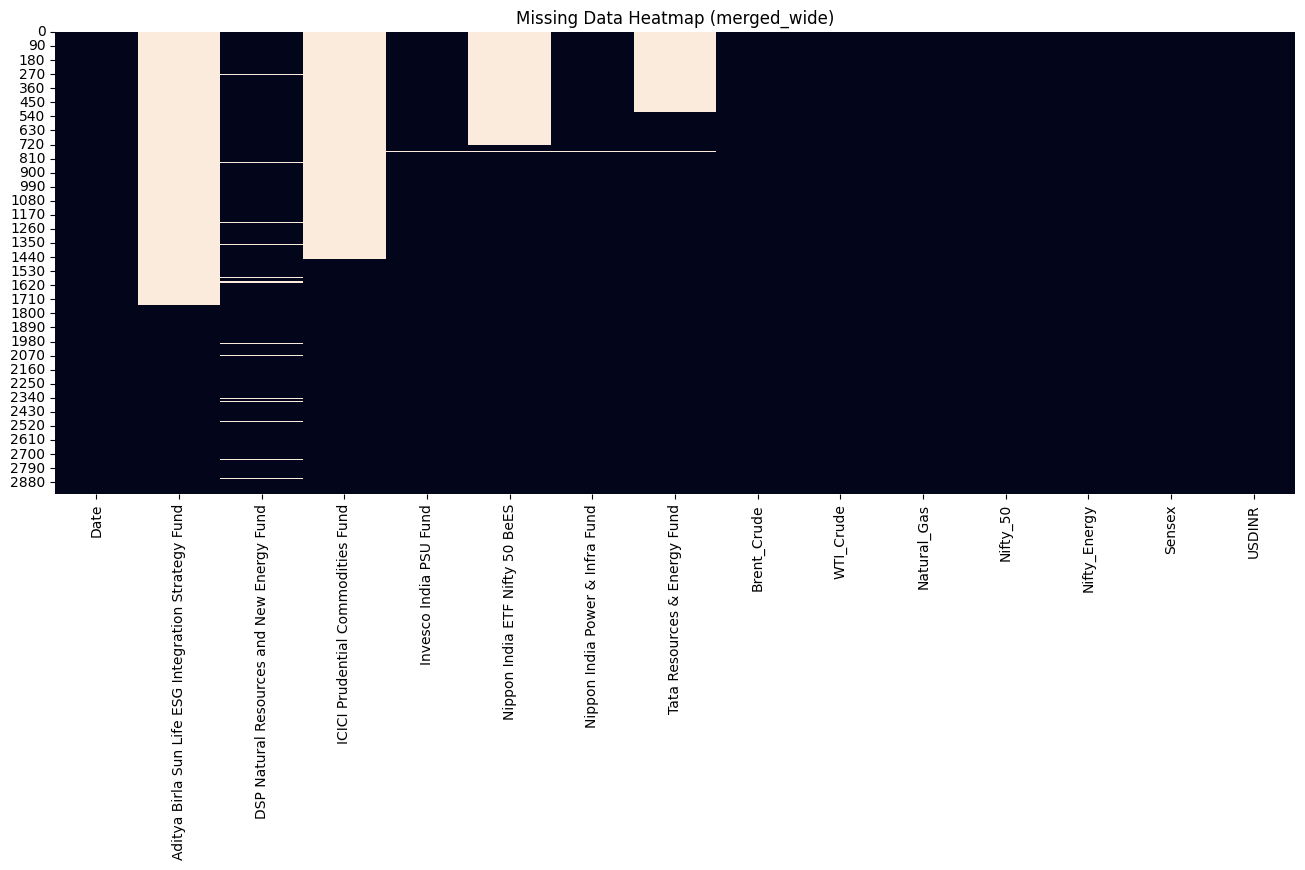

In [56]:
# Load merged_wide (skip title row)
excel_file = "Group40_Data.xlsx"
merged_wide = pd.read_excel(excel_file, sheet_name="merged_wide", header=0)

plt.figure(figsize=(16, 6))
sns.heatmap(merged_wide.isna(), cbar=False)
plt.title("Missing Data Heatmap (merged_wide)")
plt.savefig("missing_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


##Identifying launch-date structural missingness

In [57]:
# First non-null row index for each column (fund inception)
start_idx = merged_wide.notna().idxmax()
start_idx


,0
Date,0
Aditya Birla Sun Life ESG Integration Strategy Fund,1749
DSP Natural Resources and New Energy Fund,0
ICICI Prudential Commodities Fund,1451
Invesco India PSU Fund,0
Nippon India ETF Nifty 50 BeES,725
Nippon India Power & Infra Fund,0
Tata Resources & Energy Fund,515
Brent_Crude,0
WTI_Crude,0


### Identifying INTERNAL missing values (within valid date range)

In [58]:
internal_missing = {}

for col in merged_wide.columns:
    if col == "Date":
        continue

    first = merged_wide[col].first_valid_index()
    last = merged_wide[col].last_valid_index()

    if first is not None:
        # Missing values between first and last valid NAV
        mid_missing = merged_wide.loc[first:last, col].isna().sum()

        if mid_missing > 0:
            internal_missing[col] = mid_missing

internal_missing


{'Aditya Birla Sun Life ESG Integration Strategy Fund': np.int64(3),
 'DSP Natural Resources and New Energy Fund': np.int64(83),
 'ICICI Prudential Commodities Fund': np.int64(3),
 'Invesco India PSU Fund': np.int64(5),
 'Nippon India ETF Nifty 50 BeES': np.int64(2),
 'Nippon India Power & Infra Fund': np.int64(5),
 'Tata Resources & Energy Fund': np.int64(5)}

### Imputing ONLY internal missing values (fund columns)

(Not for macro indicators and not for launch-date structural missingness)

In [59]:
# Make a copy
# Reload merged_wide correctly to ensure string column names
excel_file = "final_merged.xlsx" # The file created with correct headers
merged_wide = pd.read_excel(excel_file, sheet_name="merged_wide")

clean_wide = merged_wide.copy()

# Define macro_cols to filter out from fund columns
macro_cols = ['Brent_Crude', 'WTI_Crude', 'Natural_Gas', 'Nifty_50', 'Nifty_Energy', 'Sensex', 'USDINR']

# Fund columns = all columns except Date and macro indicators
# Add isinstance(col, str) check to ensure only strings are processed
fund_columns = [col for col in merged_wide.columns
                if isinstance(col, str) and col != 'Date' and col not in macro_cols and ("Fund" in col or "ETF" in col)]

# Linear interpolation inside valid NAV range
clean_wide[fund_columns] = clean_wide[fund_columns].interpolate(method='linear')

# Backward fill for rare leading missing values
clean_wide[fund_columns] = clean_wide[fund_columns].bfill()

We do not impute launch-date missing values as it will lead to fake data.

They must remain NaN.

Instead, we extract rows where we have data for all Funds.

In [60]:
fully_available = clean_wide.dropna()


In [61]:
os.makedirs("cleaned_data", exist_ok=True)

clean_wide.to_excel("cleaned_data/clean_wide.xlsx", index=False)
clean_wide.to_csv("cleaned_data/clean_wide.csv", index=False)


#Data visualization

## 1 Univariate Analysis

Univariate analysis focused on examining the characteristics of individual features in isolation, primarily to understand their **distribution**, **central tendency**, and **spread**.

### **Distribution of Key Variables**

The distributions of the daily returns for the target mutual fund and the main macroeconomic indicators (e.g., Sensex, Crude Oil prices) were analyzed using:

- **Histograms**
- **Kernel Density Estimates (KDEs)**

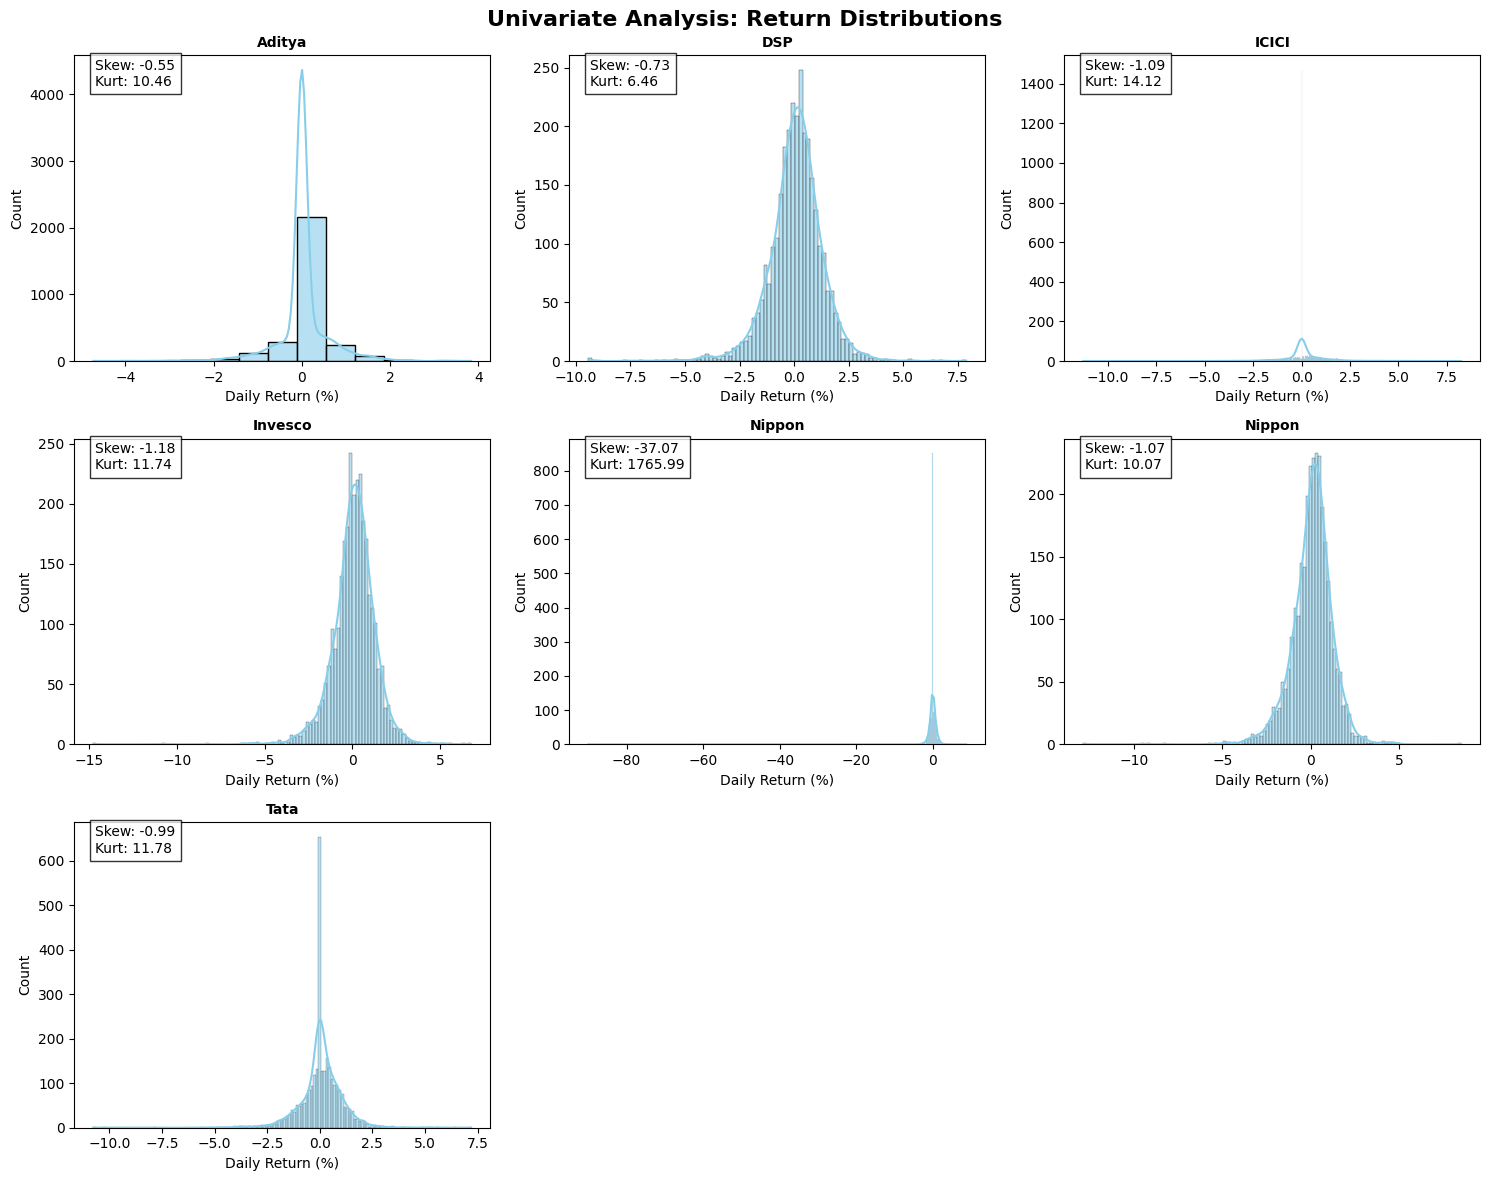

In [62]:
# Separate columns
macro_cols = ['Brent_Crude', 'WTI_Crude', 'Natural_Gas', 'Nifty_50', 'Nifty_Energy', 'Sensex', 'USDINR']
# Use clean_wide which is the prepared numerical DataFrame
fund_cols = [c for c in clean_wide.columns if c not in macro_cols and c != 'Date']

# Calculate Daily Returns (%)
daily_returns = clean_wide[fund_cols].pct_change().dropna() * 100

# --- Plotting ---
num_vars = len(fund_cols)
cols = 3
rows = (num_vars + cols - 1) // cols # Calculate rows dynamically to handle any number of funds

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i, col in enumerate(fund_cols):
    if i < len(axes): # Ensure we don't go out of bounds if rows calculation is slightly off
        sns.histplot(daily_returns[col], kde=True, ax=axes[i], color='skyblue', edgecolor='black', alpha=0.6)

        # Add stats to plot
        sk = daily_returns[col].skew()
        ku = daily_returns[col].kurtosis()
        axes[i].text(0.05, 0.9, f'Skew: {sk:.2f}\nKurt: {ku:.2f}', transform=axes[i].transAxes,
                     fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

        axes[i].set_title(col.split()[0], fontsize=10, fontweight='bold') # Short name
        axes[i].set_xlabel('Daily Return (%)')

# Hide empty plots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Univariate Analysis: Return Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Key observations include:

- **Target Fund NAV:** The Net Asset Value (NAV) distribution exhibited a *(describe shape: e.g., right-skewed, approximately normal)* pattern.
- **Daily Returns:** The daily returns followed a distribution close to normal but with **heavier tails (leptokurtosis)** — a common characteristic in financial time-series data.

### **Summary Statistics and Outlier Detection**

Violin plots were generated for each numerical feature to identify outliers and understand the **range**, **quartiles**, and **density** of the data.

As shown in **Figure 3.2**, *(include key finding: e.g., the USD/INR exchange rate showed lower volatility compared to the target fund returns, or notable outliers appeared during a specific event)*.

A **Violin Plot** combines a Box Plot with a Density Plot. It allows us to compare the *stability* of all funds side-by-side.
* **Fat Middle:** The fund is stable; returns mostly stay near 0%.
* **Long Thin Neck:** The fund is volatile; it frequently stretches to +5% or -5%.

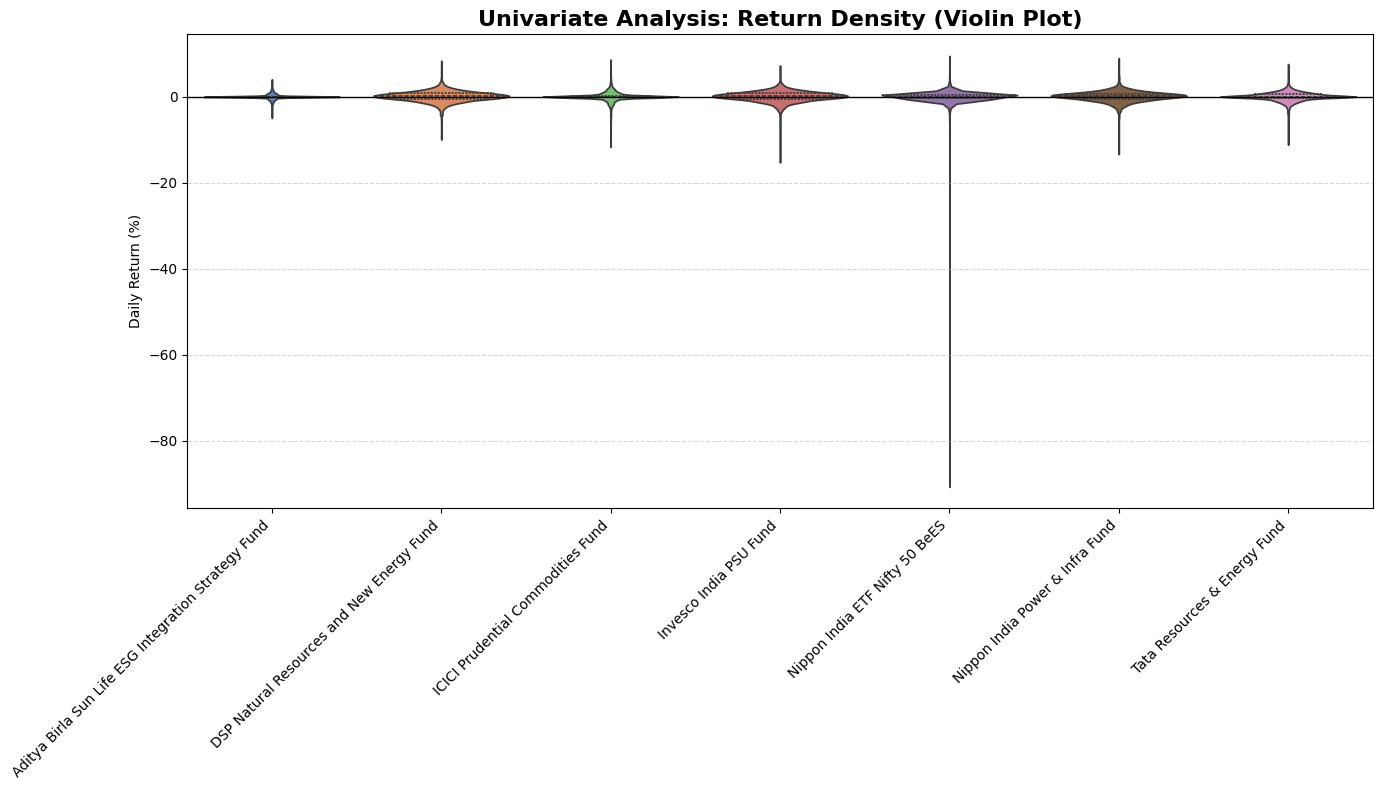

In [63]:
plt.figure(figsize=(14, 8))
sns.violinplot(data=daily_returns, palette="muted", inner="quartile")

plt.title('Univariate Analysis: Return Density (Violin Plot)', fontsize=16, fontweight='bold')
plt.ylabel('Daily Return (%)')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

Analysis:
* **The "Bulge":** Funds with a wider bulge around 0 (like the **ICICI Nifty Oil & Gas ETF**) are more consistent. Their returns are tightly clustered around the mean.
* **The "Stretch":** Funds that look like long, thin needles (like the **Invesco PSU Fund**) are highly unpredictable. Their density is spread out over a wide range of positive and negative returns.

## 3.2 Multivariate Analysis

Multivariate analysis explored the **relationships** and **dependencies** between multiple variables, which is essential for identifying potential predictors and evaluating multicollinearity.



### **Correlation Analysis**

A **Pearson correlation heatmap** was generated across all numerical features to visualize linear relationships.

Key findings include:

- **Target–Feature Correlation:** The target fund’s daily returns showed *(describe: e.g., moderate positive correlation)* with the Sensex index returns.
- **Feature–Feature Correlation:** Strong positive collinearity was observed between variables such as **Brent Crude** and **WTI Crude** prices.


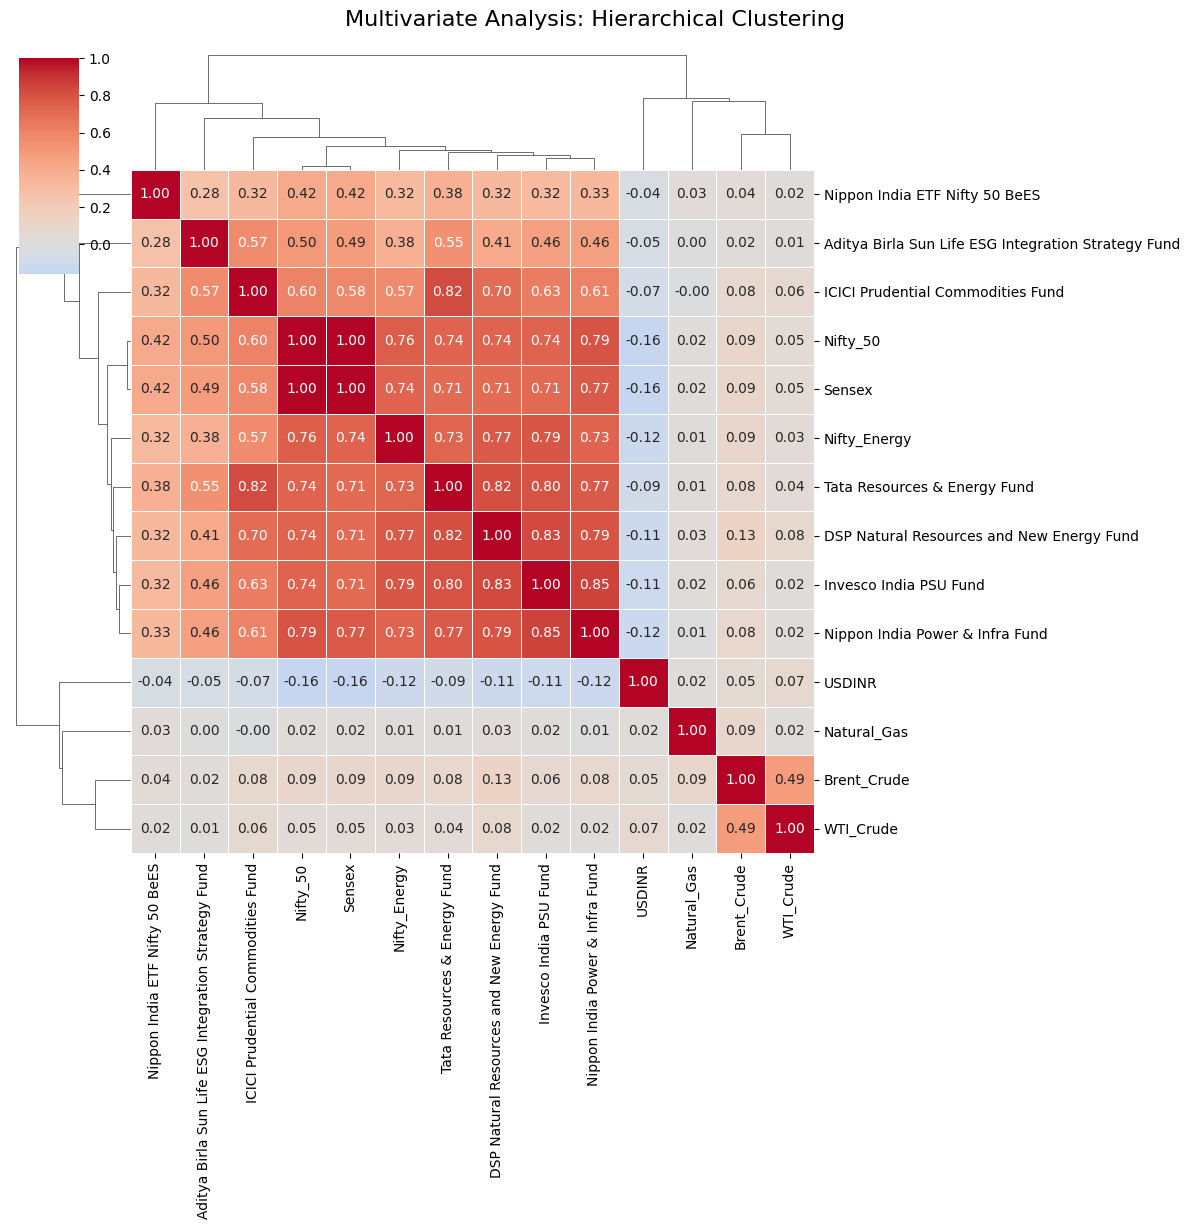

In [64]:
# Calculate Correlation Matrix including Macro Data
# Use the 'clean_wide' DataFrame and drop the 'Date' column for correlation of NAVs and original macros
all_data = clean_wide.drop(columns='Date').pct_change().dropna()
corr_matrix = all_data.corr()

# Create Clustermap
g = sns.clustermap(corr_matrix, cmap='coolwarm', center=0, figsize=(12, 12),
                   annot=True, fmt=".2f", linewidths=0.5, dendrogram_ratio=0.15)

g.fig.suptitle('Multivariate Analysis: Hierarchical Clustering', fontsize=16, y=1.02)
plt.show()

Analysis:
* **Clusters:** Look at the tree diagram (dendrogram) on the left.
    * You will likely see a large cluster of **Funds + Nifty Energy**. This confirms they are all playing the same theme.
    * You might see **Brent Crude** and **WTI Crude** forming a separate cluster.
* **Decoupling:** If **Brent Crude** is largely blue (negative correlation) against the funds, it confirms our earlier finding: These funds are *not* a direct proxy for oil prices; they are a proxy for Indian infrastructure *consumption* of energy.

### **Time-Series Plots**

The temporal dynamics of the target fund’s NAV along with key macroeconomic indicators (e.g., Sensex, USD/INR) were examined using **time-series line plots**.

 the target fund exhibited **co-movement with the Sensex**, particularly during periods of high market volatility—an expected behavior for energy-linked financial instruments.

"Drawdown" measures the percentage decline from a fund's historical peak. This visualization shows the "pain" an investor would feel during market dips. It answers: *What is the worst loss I would have suffered if I bought at the top?* Deep drawdowns take significantly longer to recover from.

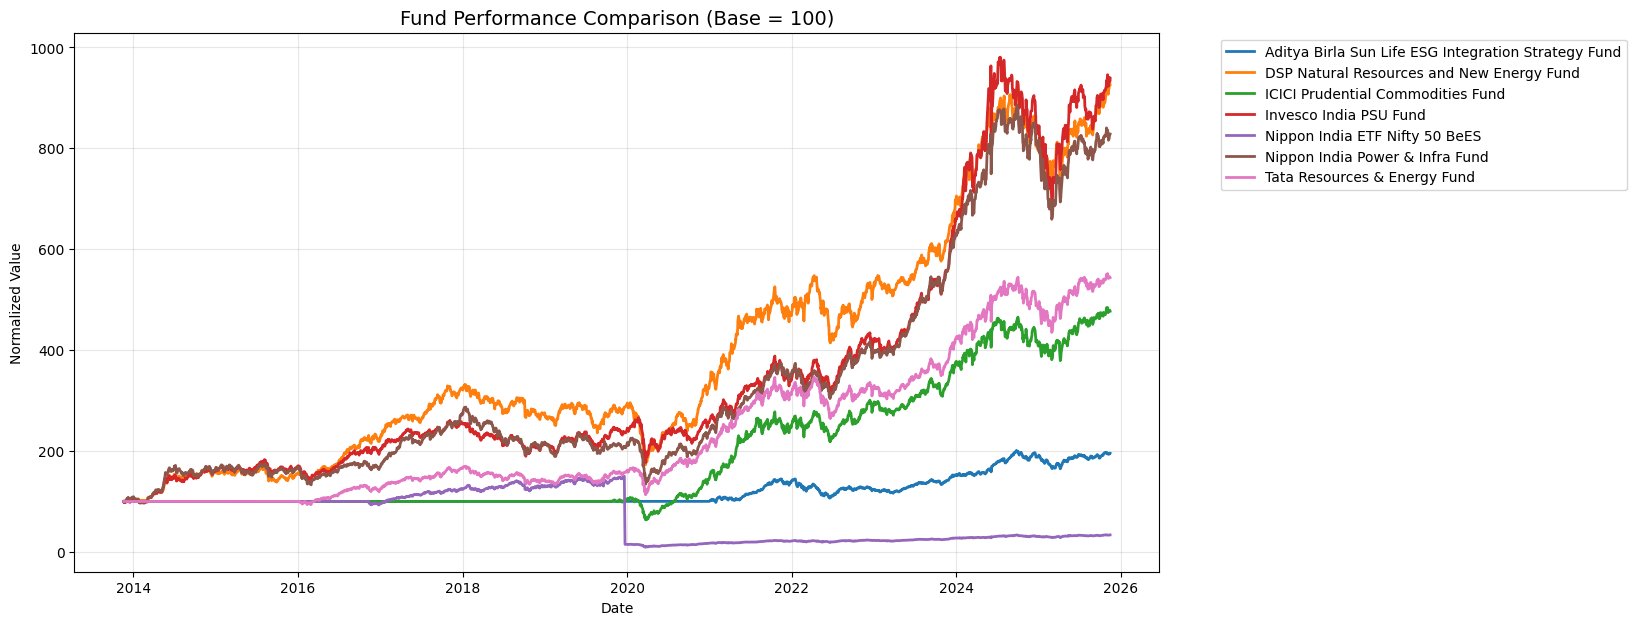

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the clean_wide data
# Make sure to provide the correct path to your cleaned_data folder if it's not in the root
df = pd.read_excel("cleaned_data/clean_wide.xlsx")

# Convert 'Date' to datetime and set as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Separate columns
macro_cols = ['Brent_Crude', 'WTI_Crude', 'Natural_Gas', 'Nifty_50', 'Nifty_Energy', 'Sensex', 'USDINR']
# Use clean_wide which is the prepared numerical DataFrame
fund_cols = [c for c in df.columns if c not in macro_cols and c != 'Date']

plt.figure(figsize=(14, 7))

# Normalize to 100
normalized_df = df[fund_cols] / df[fund_cols].iloc[0] * 100

for col in normalized_df.columns:
    plt.plot(normalized_df.index, normalized_df[col], label=col, linewidth=2)

plt.title('Fund Performance Comparison (Base = 100)', fontsize=14)
plt.ylabel('Normalized Value')
plt.xlabel('Date')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

Analysis:
* **High Risk:** The **Invesco India PSU Fund** shows the deepest drawdowns (around -30% at its worst point). While it has high returns, it is extremely volatile, meaning investors must have a high tolerance for risk.
* **Stability:** The **Aditya Birla Sun Life ESG Fund** and **Tata Resources & Energy Fund** show relatively shallower drawdowns compared to the aggressive PSU fund, indicating they offer a smoother ride during downturns.
* **Recovery:** Notice how some funds recover quickly (V-shaped recovery) while others stay "underwater" for longer periods. The ETF (ICICI Oil & Gas) tends to drag during sector-wide slumps.

#Feature Engineering


##Feature Extraction

In [66]:
df.columns.tolist()


['Aditya Birla Sun Life ESG Integration Strategy Fund',
 'DSP Natural Resources and New Energy Fund',
 'ICICI Prudential Commodities Fund',
 'Invesco India PSU Fund',
 'Nippon India ETF Nifty 50 BeES',
 'Nippon India Power & Infra Fund',
 'Tata Resources & Energy Fund',
 'Brent_Crude',
 'WTI_Crude',
 'Natural_Gas',
 'Nifty_50',
 'Nifty_Energy',
 'Sensex',
 'USDINR']

In [67]:
# fund / macro column setup

fund_cols = [
    'Aditya Birla Sun Life ESG Integration Strategy Fund',
    'DSP Natural Resources and New Energy Fund',
    'ICICI Prudential Commodities Fund',
    'ICICI Prudential Nifty Oil & Gas ETF',
    'Invesco India PSU Fund',
    'Nippon India ETF Nifty 50 BeES',
    'Nippon India Power & Infra Fund',
    'SBI Energy Opportunities Fund',
    'Tata Resources & Energy Fund'
]

macro_cols = ['Brent_Crude', 'WTI_Crude', 'Natural_Gas', 'Nifty_50', 'Nifty_Energy', 'Sensex', 'USDINR']

# fallback auto-detect: if any fund from fund_cols doesn't exist, auto-detect:
existing_funds = [c for c in fund_cols if c in df.columns]
if len(existing_funds) < len(fund_cols):
    # Auto-detect: treat numeric columns except known macro_cols as funds
    numeric_cols = df.select_dtypes(include=['float64','int64']).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != 'Date']
    # remove macros if they exist, and remove any obvious non-fund columns like index numbers
    auto_funds = [c for c in numeric_cols if c not in macro_cols]
    fund_cols = auto_funds
    print("Using auto-detected fund columns:", fund_cols)
else:
    fund_cols = existing_funds
    print("Using provided fund columns:", fund_cols)

# also detect macros that exist in dataframe
macro_cols = [c for c in macro_cols if c in df.columns]
print("Macro columns used:", macro_cols)


Using auto-detected fund columns: ['Aditya Birla Sun Life ESG Integration Strategy Fund', 'DSP Natural Resources and New Energy Fund', 'ICICI Prudential Commodities Fund', 'Invesco India PSU Fund', 'Nippon India ETF Nifty 50 BeES', 'Nippon India Power & Infra Fund', 'Tata Resources & Energy Fund']
Macro columns used: ['Brent_Crude', 'WTI_Crude', 'Natural_Gas', 'Nifty_50', 'Nifty_Energy', 'Sensex', 'USDINR']


A. Returns (for all funds + macros)

In [68]:
for col in fund_cols + macro_cols:
    df[col + "_Return"] = df[col].pct_change()
    df[col + "_LogReturn"] = np.log(df[col] / df[col].shift(1))



/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Selecting ONE Target Fund

In [69]:
target_fund = "Aditya Birla Sun Life ESG Integration Strategy Fund"


Rolling Mean & Rolling Volatility — ONLY for target fund

In [70]:
df[target_fund + "_MA7"] = df[target_fund].rolling(7).mean()
df[target_fund + "_MA30"] = df[target_fund].rolling(30).mean()
df[target_fund + "_Vol7"] = df[target_fund].rolling(7).std()
df[target_fund + "_Vol30"] = df[target_fund].rolling(30).std()


Lag Features — ONLY target fund

In [71]:
df[target_fund + "_Lag1"] = df[target_fund].shift(1)
df[target_fund + "_Lag3"] = df[target_fund].shift(3)
df[target_fund + "_Lag7"] = df[target_fund].shift(7)


Macro Interactions — ONLY target fund × selected macros

In [72]:
for m in ["Brent_Crude", "WTI_Crude", "USDINR"]:
    df[f"{target_fund}_x_{m}"] = df[target_fund] * df[m]
    df[f"{target_fund}_Return_x_{m}_Return"] = (
        df[target_fund + "_Return"] * df[m + "_Return"]
    )


Rolling Correlation — target fund vs key macro (optional)

In [73]:
df[target_fund + "_Corr30_Brent"] = (
    df[target_fund + "_Return"].rolling(30).corr(df["Brent_Crude_Return"])
)


Removing early NaN rows

In [74]:
df_final = df.dropna().reset_index(drop=True)
df_final.shape

(1205, 56)

In [75]:
df_fs = df_final.copy()
df_fs.head()


,Aditya Birla Sun Life ESG Integration Strategy Fund,DSP Natural Resources and New Energy Fund,ICICI Prudential Commodities Fund,Invesco India PSU Fund,Nippon India ETF Nifty 50 BeES,Nippon India Power & Infra Fund,Tata Resources & Energy Fund,Brent_Crude,WTI_Crude,Natural_Gas,...,Aditya Birla Sun Life ESG Integration Strategy Fund_Lag1,Aditya Birla Sun Life ESG Integration Strategy Fund_Lag3,Aditya Birla Sun Life ESG Integration Strategy Fund_Lag7,Aditya Birla Sun Life ESG Integration Strategy Fund_x_Brent_Crude,Aditya Birla Sun Life ESG Integration Strategy Fund_Return_x_Brent_Crude_Return,Aditya Birla Sun Life ESG Integration Strategy Fund_x_WTI_Crude,Aditya Birla Sun Life ESG Integration Strategy Fund_Return_x_WTI_Crude_Return,Aditya Birla Sun Life ESG Integration Strategy Fund_x_USDINR,Aditya Birla Sun Life ESG Integration Strategy Fund_Return_x_USDINR_Return,Aditya Birla Sun Life ESG Integration Strategy Fund_Corr30_Brent
0,10.04,38.4800,14.45,21.75,149.2799,110.1833,21.0698,51.340000,48.400002,2.422,...,10.02,10.02,10.02,515.453602,0.000010,485.936015,0.000017,737.474124,-0.000002,-0.017129
1,10.05,38.5400,14.53,21.83,149.2771,110.0627,21.2469,51.799999,48.520000,2.539,...,10.04,10.02,10.02,520.589992,0.000009,487.626005,0.000002,734.996727,-0.000004,0.009251
2,10.07,39.2615,14.68,21.97,149.6694,111.2808,21.3942,51.799999,48.520000,2.539,...,10.05,10.02,10.02,521.625992,0.000000,488.596405,0.000000,736.459407,0.000000,-0.035684
3,10.15,39.9830,15.34,22.29,150.8892,112.9017,21.8857,51.090000,47.619999,2.581,...,10.07,10.04,10.02,518.563502,-0.000109,483.342989,-0.000147,741.883829,-0.000005,-0.244249
4,10.26,39.8650,15.49,22.32,151.5999,112.5804,21.7826,53.599998,49.930000,2.702,...,10.15,10.05,10.02,549.935984,0.000532,512.281803,0.000526,752.263197,0.000034,0.260418


In [76]:
df.final = df_final.copy()
df.final.to_excel("df_final.xlsx", index=False)

/tmp/ipython-input-390794423.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.final = df_final.copy()


##FEATURE SELECTION

In [77]:
df_fs = df_final.copy()   # df_final from feature engineering
df_fs.head()


,Aditya Birla Sun Life ESG Integration Strategy Fund,DSP Natural Resources and New Energy Fund,ICICI Prudential Commodities Fund,Invesco India PSU Fund,Nippon India ETF Nifty 50 BeES,Nippon India Power & Infra Fund,Tata Resources & Energy Fund,Brent_Crude,WTI_Crude,Natural_Gas,...,Aditya Birla Sun Life ESG Integration Strategy Fund_Lag1,Aditya Birla Sun Life ESG Integration Strategy Fund_Lag3,Aditya Birla Sun Life ESG Integration Strategy Fund_Lag7,Aditya Birla Sun Life ESG Integration Strategy Fund_x_Brent_Crude,Aditya Birla Sun Life ESG Integration Strategy Fund_Return_x_Brent_Crude_Return,Aditya Birla Sun Life ESG Integration Strategy Fund_x_WTI_Crude,Aditya Birla Sun Life ESG Integration Strategy Fund_Return_x_WTI_Crude_Return,Aditya Birla Sun Life ESG Integration Strategy Fund_x_USDINR,Aditya Birla Sun Life ESG Integration Strategy Fund_Return_x_USDINR_Return,Aditya Birla Sun Life ESG Integration Strategy Fund_Corr30_Brent
0,10.04,38.4800,14.45,21.75,149.2799,110.1833,21.0698,51.340000,48.400002,2.422,...,10.02,10.02,10.02,515.453602,0.000010,485.936015,0.000017,737.474124,-0.000002,-0.017129
1,10.05,38.5400,14.53,21.83,149.2771,110.0627,21.2469,51.799999,48.520000,2.539,...,10.04,10.02,10.02,520.589992,0.000009,487.626005,0.000002,734.996727,-0.000004,0.009251
2,10.07,39.2615,14.68,21.97,149.6694,111.2808,21.3942,51.799999,48.520000,2.539,...,10.05,10.02,10.02,521.625992,0.000000,488.596405,0.000000,736.459407,0.000000,-0.035684
3,10.15,39.9830,15.34,22.29,150.8892,112.9017,21.8857,51.090000,47.619999,2.581,...,10.07,10.04,10.02,518.563502,-0.000109,483.342989,-0.000147,741.883829,-0.000005,-0.244249
4,10.26,39.8650,15.49,22.32,151.5999,112.5804,21.7826,53.599998,49.930000,2.702,...,10.15,10.05,10.02,549.935984,0.000532,512.281803,0.000526,752.263197,0.000034,0.260418


In [78]:
target_fund = "Aditya Birla Sun Life ESG Integration Strategy Fund"
target = target_fund + "_Return"


In [79]:
X = df_fs.drop(columns=[target])
y = df_fs[target]

### FILTER METHOD 1: Correlation Heatmap

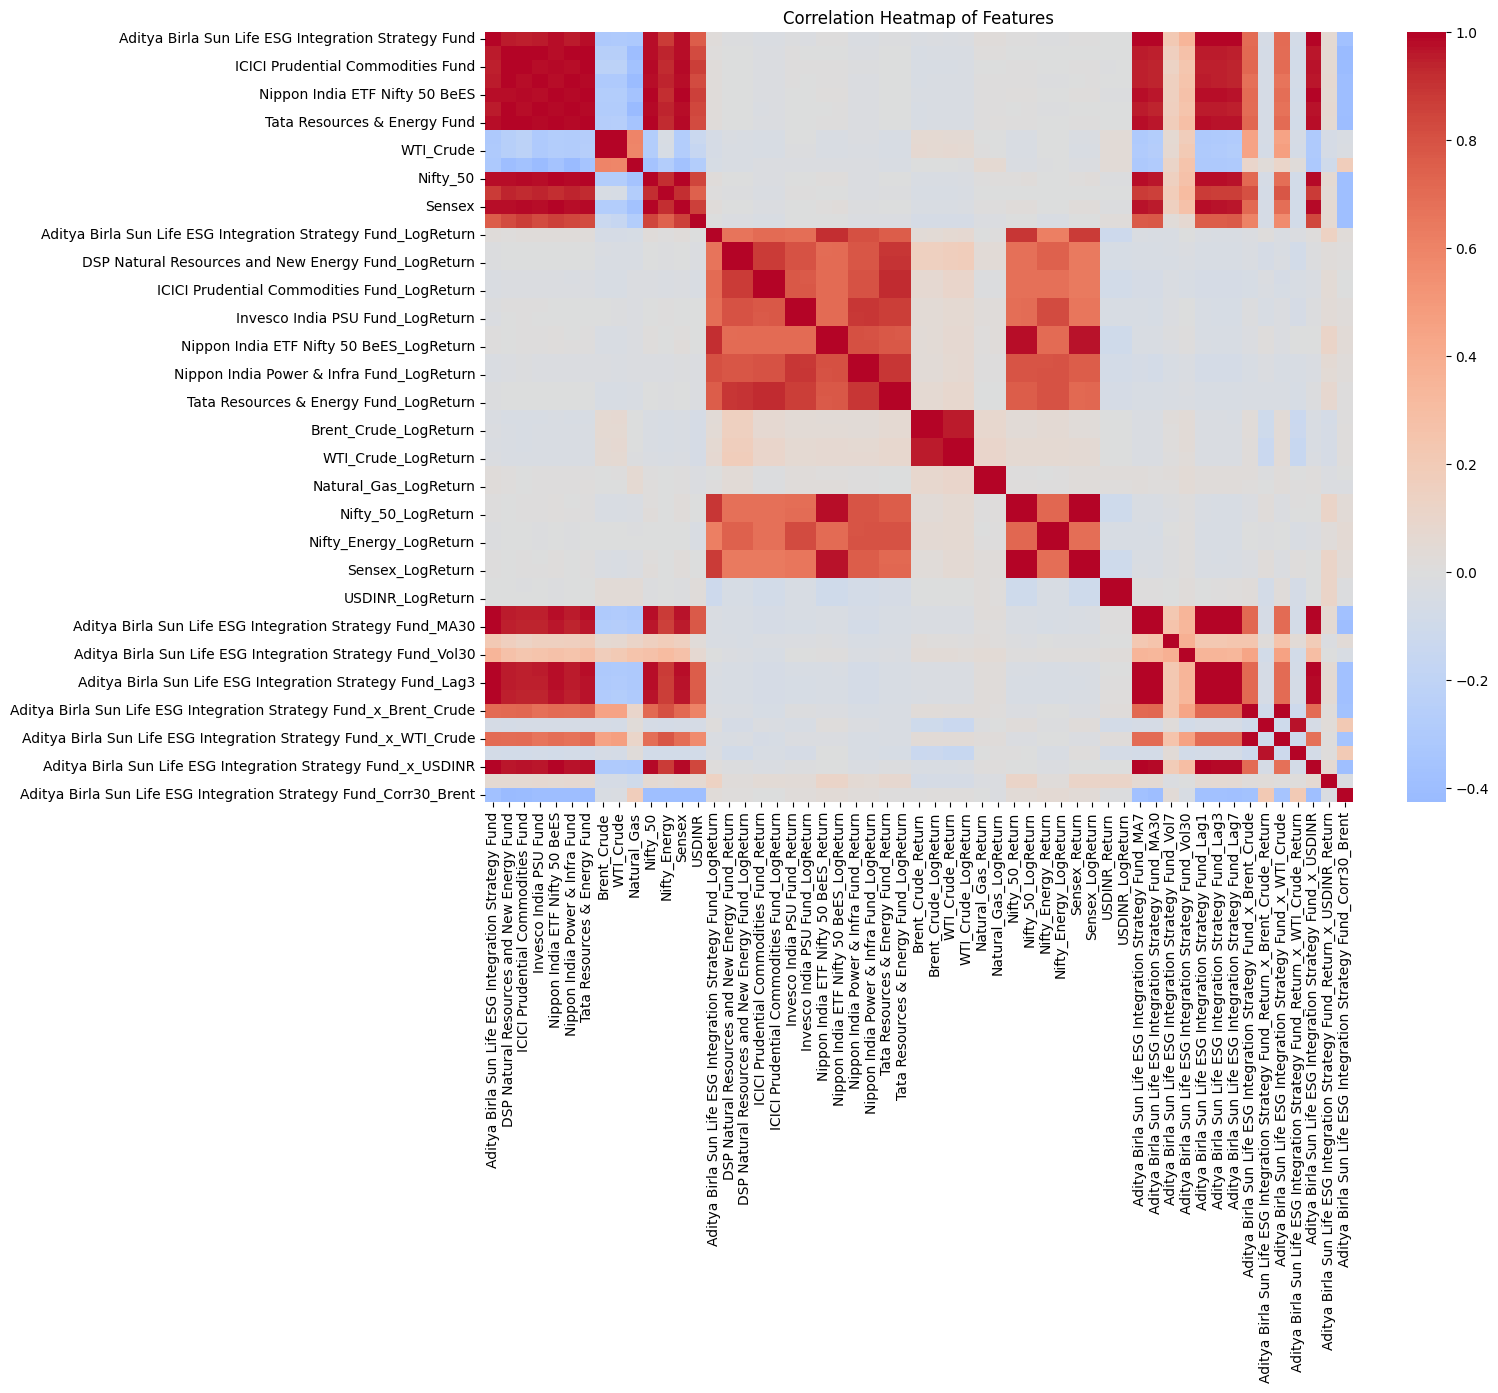

In [80]:
plt.figure(figsize=(14,10))
sns.heatmap(X.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Features")
plt.show()


### FILTER METHOD 2: Variance Threshold

In [81]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.0001)
vt.fit(X)

low_var_cols = X.columns[~vt.get_support()]
low_var_cols


Index(['Aditya Birla Sun Life ESG Integration Strategy Fund_LogReturn',
       'Nippon India ETF Nifty 50 BeES_Return',
       'Nippon India ETF Nifty 50 BeES_LogReturn', 'Nifty_50_Return',
       'Nifty_50_LogReturn', 'Sensex_Return', 'Sensex_LogReturn',
       'USDINR_Return', 'USDINR_LogReturn',
       'Aditya Birla Sun Life ESG Integration Strategy Fund_Return_x_Brent_Crude_Return',
       'Aditya Birla Sun Life ESG Integration Strategy Fund_Return_x_WTI_Crude_Return',
       'Aditya Birla Sun Life ESG Integration Strategy Fund_Return_x_USDINR_Return'],
      dtype='object')

Removing low-variance features:

In [82]:
X_reduced = X.drop(columns=low_var_cols)
X_reduced.shape


(1205, 43)

### WRAPPER METHOD: RFE

In [83]:
#RFE for Top 10 Features
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
rfe = RFE(model_lr, n_features_to_select=10)
rfe.fit(X_reduced, y)

selected_rfe = X_reduced.columns[rfe.support_]
selected_rfe


Index(['DSP Natural Resources and New Energy Fund_Return',
       'DSP Natural Resources and New Energy Fund_LogReturn',
       'Invesco India PSU Fund_Return', 'Invesco India PSU Fund_LogReturn',
       'Nippon India Power & Infra Fund_Return',
       'Nippon India Power & Infra Fund_LogReturn',
       'Tata Resources & Energy Fund_Return',
       'Tata Resources & Energy Fund_LogReturn', 'Nifty_Energy_Return',
       'Nifty_Energy_LogReturn'],
      dtype='object')

### EMBEDDED METHOD: Random Forest Importance

In [84]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_reduced, y)

importances = pd.Series(rf.feature_importances_, index=X_reduced.columns)
importances.sort_values(ascending=False).head(15)


,0
Nippon India Power & Infra Fund_LogReturn,0.321461
Nippon India Power & Infra Fund_Return,0.311010
Tata Resources & Energy Fund_LogReturn,0.031599
Tata Resources & Energy Fund_Return,0.030790
Aditya Birla Sun Life ESG Integration Strategy Fund_Vol7,0.022707
ICICI Prudential Commodities Fund_Return,0.017531
Natural_Gas,0.017047
Aditya Birla Sun Life ESG Integration Strategy Fund_Corr30_Brent,0.016391
ICICI Prudential Commodities Fund_LogReturn,0.015914
Aditya Birla Sun Life ESG Integration Strategy Fund_Vol30,0.014668


##FINAL SELECTED FEATURES:
Combining Top RF + RFE

In [85]:
top_rf = list(importances.sort_values(ascending=False).head(15).index)
top_rfe = list(selected_rfe)

final_features = list(set(top_rf + top_rfe))
final_features


['ICICI Prudential Commodities Fund_LogReturn',
 'Natural_Gas_LogReturn',
 'DSP Natural Resources and New Energy Fund_Return',
 'Nippon India Power & Infra Fund_Return',
 'Tata Resources & Energy Fund_LogReturn',
 'Natural_Gas_Return',
 'Natural_Gas',
 'Nippon India Power & Infra Fund_LogReturn',
 'USDINR',
 'Invesco India PSU Fund_LogReturn',
 'Aditya Birla Sun Life ESG Integration Strategy Fund_Corr30_Brent',
 'Tata Resources & Energy Fund_Return',
 'Aditya Birla Sun Life ESG Integration Strategy Fund_Vol7',
 'Invesco India PSU Fund_Return',
 'ICICI Prudential Commodities Fund_Return',
 'Nifty_Energy_Return',
 'WTI_Crude',
 'Nifty_Energy_LogReturn',
 'Aditya Birla Sun Life ESG Integration Strategy Fund_Vol30',
 'DSP Natural Resources and New Energy Fund_LogReturn']

Final Dataset For Modeling

In [86]:
X_final = df_fs[final_features]
y_final = df_fs[target]

X_final.shape, y_final.shape


((1205, 20), (1205,))

#Model Fitting

Train–Test Split + Scaling

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = X_final
y = y_final

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Importing Models & Metrics

In [88]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


Helper Function to Evaluate Models

In [89]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return mae, rmse, r2


Training All Regression Models

In [90]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42)
}

results = {}

for name, model in models.items():
    mae, rmse, r2 = evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test)
    results[name] = [mae, rmse, r2]

results_df = pd.DataFrame(results, index=["MAE", "RMSE", "R2"]).T
results_df


,MAE,RMSE,R2
Linear Regression,0.004174,0.005683,0.679535
Ridge Regression,0.004199,0.005671,0.680902
Lasso Regression,0.004408,0.005958,0.647751
Random Forest,0.004359,0.005808,0.665306


Visualizing the outputs

In [91]:
fitted_models = {}
preds = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    fitted_models[name] = model
    preds[name] = y_pred

# quick check
list(preds.keys())

['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Random Forest']

Actual vs Predicted scatter + 45° line

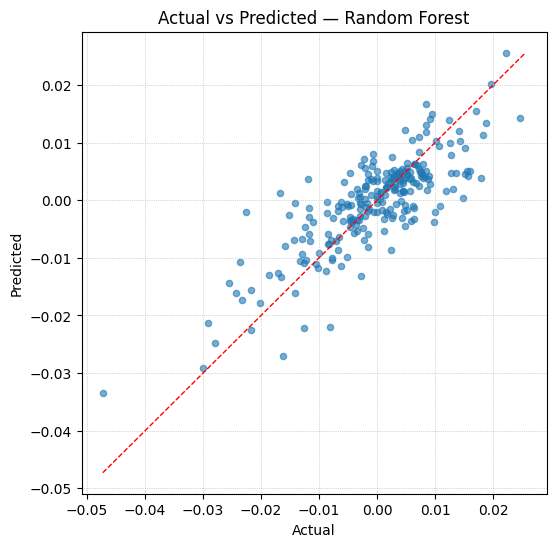

In [92]:
def plot_actual_vs_pred(y_true, y_pred, title="Actual vs Predicted", savepath=None):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.6, s=20)
    # 45-degree line
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx], color='red', linewidth=1, linestyle='--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.grid(True, linestyle=':', linewidth=0.5)
    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=200)
    plt.show()

# Example: plot for Random Forest
plot_actual_vs_pred(y_test, preds["Random Forest"],
                    title="Actual vs Predicted — Random Forest",
                    savepath="/content/actual_vs_pred_rf.png")


#### Time series: Actual vs Predicted (first N points)

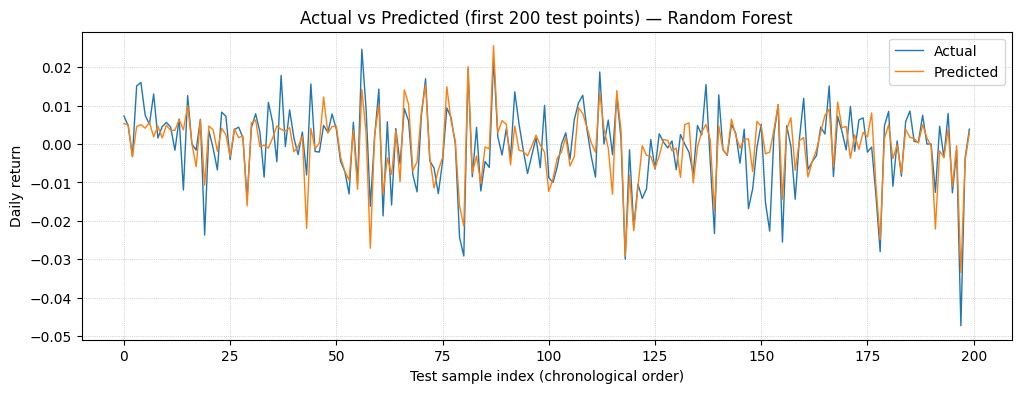

In [93]:
# Cell C
def plot_timeseries_actual_pred(y_true, y_pred, n=200, title="Actual vs Predicted (time series)", savepath=None):
    plt.figure(figsize=(12,4))
    idx = np.arange(len(y_true))  # integer index
    plt.plot(idx[:n], y_true.values[:n], label="Actual", linewidth=1)
    plt.plot(idx[:n], y_pred[:n], label="Predicted", linewidth=1)
    plt.xlabel("Test sample index (chronological order)")
    plt.ylabel("Daily return")
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle=':', linewidth=0.5)
    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=200)
    plt.show()

# Plot first 200 test points for Random Forest
plot_timeseries_actual_pred(y_test.reset_index(drop=True), preds["Random Forest"], n=200,
                           title="Actual vs Predicted (first 200 test points) — Random Forest",
                           savepath="/content/timeseries_rf.png")


#### Residuals vs Predicted

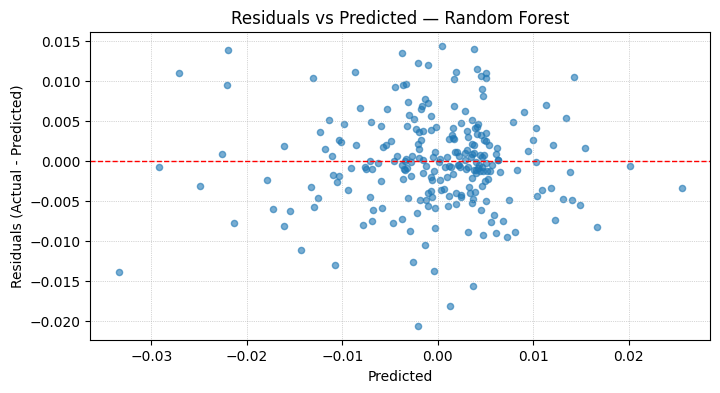

In [94]:
# Cell D
def plot_residuals_vs_pred(y_true, y_pred, title="Residuals vs Predicted", savepath=None):
    residuals = y_true - y_pred
    plt.figure(figsize=(8,4))
    plt.scatter(y_pred, residuals, alpha=0.6, s=20)
    plt.axhline(0, color='red', linestyle='--', linewidth=1)
    plt.xlabel("Predicted")
    plt.ylabel("Residuals (Actual - Predicted)")
    plt.title(title)
    plt.grid(True, linestyle=':', linewidth=0.5)
    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=200)
    plt.show()

plot_residuals_vs_pred(y_test, preds["Random Forest"],
                       title="Residuals vs Predicted — Random Forest",
                       savepath="/content/residuals_vs_pred_rf.png")


##Classification

Target Variable Creation & Imports

In [95]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
# --- 1. Create Classification Target Variables ---
# y_train_cls = 1 (Up) if return > 0, else 0 (Down/No Change)
y_train_cls = np.where(y_train > 0, 1, 0)
y_test_cls = np.where(y_test > 0, 1, 0)

print(f"Total samples: {len(X_final)}")
print(f"Train samples (80%): {len(y_train_cls)}")
print(f"Test samples (20%): {len(y_test_cls)}")

print("\nTraining Set Classification Target Distribution:")
train_distribution = pd.Series(y_train_cls).value_counts(normalize=True) * 100
print(f"Class 1 (Up): {train_distribution.loc[1]:.2f}%")
print(f"Class 0 (Down/Flat): {train_distribution.loc[0]:.2f}%")

Total samples: 1205
Train samples (80%): 964
Test samples (20%): 241

Training Set Classification Target Distribution:
Class 1 (Up): 54.67%
Class 0 (Down/Flat): 45.33%


Training and Evaluation

In [96]:
# Initialize models
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# --- Train Models ---
log_reg_model.fit(X_train_scaled, y_train_cls)
rf_classifier.fit(X_train_scaled, y_train_cls)

# --- Predict on Test Set ---
y_pred_lr = log_reg_model.predict(X_test_scaled)
y_pred_rf = rf_classifier.predict(X_test_scaled)

# --- Evaluate Models ---
def evaluate_classification_model(y_test, y_pred, model_name):
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Print detailed report
    print(f"\n--- {model_name} Performance ---")
    print(classification_report(y_test, y_pred, target_names=['Down/Flat (0)', 'Up (1)']))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # Return metrics for summary table
    return [model_name, accuracy, precision, recall, f1]

# Store results
results_list = []
results_list.append(evaluate_classification_model(y_test_cls, y_pred_lr, "Logistic Regression"))
results_list.append(evaluate_classification_model(y_test_cls, y_pred_rf, "Random Forest Classifier"))

# Convert to DataFrame for final reporting
df_results_cls = pd.DataFrame(results_list, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
print("\nClassification Results Summary (for LaTeX Table):")
print(df_results_cls.to_markdown(index=False, floatfmt=".4f"))


--- Logistic Regression Performance ---
               precision    recall  f1-score   support

Down/Flat (0)       0.81      0.77      0.79       118
       Up (1)       0.79      0.82      0.80       123

     accuracy                           0.80       241
    macro avg       0.80      0.80      0.80       241
 weighted avg       0.80      0.80      0.80       241

Confusion Matrix:
 [[ 91  27]
 [ 22 101]]

--- Random Forest Classifier Performance ---
               precision    recall  f1-score   support

Down/Flat (0)       0.79      0.75      0.77       118
       Up (1)       0.77      0.80      0.79       123

     accuracy                           0.78       241
    macro avg       0.78      0.78      0.78       241
 weighted avg       0.78      0.78      0.78       241

Confusion Matrix:
 [[88 30]
 [24 99]]

Classification Results Summary (for LaTeX Table):
| Model                    |   Accuracy |   Precision |   Recall |   F1-Score |
|:-------------------------|--------

##ML Algorithms

Imports and Model Initialization




In [97]:
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report



svc_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
xgb_model = XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    learning_rate=0.05,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
print("Advanced models initialized.")

Advanced models initialized.


Training, Prediction, and Evaluation

In [98]:
print("Training SVC...")
svc_model.fit(X_train_scaled, y_train_cls)

print("Training XGBoost...")
xgb_model.fit(X_train_scaled, y_train_cls)


# --- Predict on Test Set ---
y_pred_svc = svc_model.predict(X_test_scaled)
y_pred_xgb = xgb_model.predict(X_test_scaled)


def evaluate_classification_model(y_test, y_pred, model_name, results_list):
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Print detailed report
    print(f"\n--- {model_name} Performance ---")
    print(classification_report(y_test, y_pred, target_names=['Down/Flat (0)', 'Up (1)']))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # Append to the existing results list
    results_list.append([model_name, accuracy, precision, recall, f1])
    return results_list

results_list = evaluate_classification_model(y_test_cls, y_pred_svc, "Support Vector Machine (SVC)", results_list)
results_list = evaluate_classification_model(y_test_cls, y_pred_xgb, "XGBoost Classifier", results_list)

# Convert all results to DataFrame for final reporting
df_results_all = pd.DataFrame(results_list, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

print("\n\n--- ALL CLASSIFICATION RESULTS SUMMARY ---")
# Use the final metrics from this output to populate your LaTeX table
print(df_results_all.to_markdown(index=False, floatfmt=".4f"))

Training SVC...
Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:04:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Support Vector Machine (SVC) Performance ---
               precision    recall  f1-score   support

Down/Flat (0)       0.80      0.77      0.78       118
       Up (1)       0.79      0.81      0.80       123

     accuracy                           0.79       241
    macro avg       0.79      0.79      0.79       241
 weighted avg       0.79      0.79      0.79       241

Confusion Matrix:
 [[ 91  27]
 [ 23 100]]

--- XGBoost Classifier Performance ---
               precision    recall  f1-score   support

Down/Flat (0)       0.77      0.73      0.75       118
       Up (1)       0.75      0.79      0.77       123

     accuracy                           0.76       241
    macro avg       0.76      0.76      0.76       241
 weighted avg       0.76      0.76      0.76       241

Confusion Matrix:
 [[86 32]
 [26 97]]


--- ALL CLASSIFICATION RESULTS SUMMARY ---
| Model                        |   Accuracy |   Precision |   Recall |   F1-Score |
|:-----------------------------|---

#Performance Evaluation Against Market Benchmarks

Fund Performance Metrics

In [99]:
from sklearn.linear_model import LinearRegression
FUND_NAV_COL = 'Aditya Birla Sun Life ESG Integration Strategy Fund'
BENCHMARK_NAV_COL = 'Nifty_50'
df = df.sort_index()

# Compute Daily Returns (Percentage Change)
df['Fund_Return'] = df[FUND_NAV_COL].pct_change()
df['Market_Return'] = df[BENCHMARK_NAV_COL].pct_change()

# Drop the first row of returns (which will be NaN)
df_clean = df.dropna(subset=['Fund_Return', 'Market_Return']).copy()

X_market = df_clean[['Market_Return']]
y_fund = df_clean['Fund_Return']

reg = LinearRegression()
reg.fit(X_market, y_fund)

beta = reg.coef_[0]

RISK_FREE_ANNUAL = 0.07
RISK_FREE_DAILY = RISK_FREE_ANNUAL / 252 # 252 trading days

# Calculate Daily Alpha: R_fund - [R_f + Beta * (R_market - R_f)]
df_clean['Alpha_Daily'] = df_clean['Fund_Return'] - (
    RISK_FREE_DAILY + beta * (df_clean['Market_Return'] - RISK_FREE_DAILY)
)

alpha_mean = df_clean['Alpha_Daily'].mean()
alpha_annual = alpha_mean * 252

r_squared = reg.score(X_market, y_fund)

# Fund metrics
fund_mean_return = df_clean['Fund_Return'].mean()
fund_std_dev = df_clean['Fund_Return'].std()

# 1. Sharpe Ratio: (R_fund - R_f) / StdDev(R_fund)
sharpe_ratio_daily = (fund_mean_return - RISK_FREE_DAILY) / fund_std_dev
sharpe_ratio_annual = sharpe_ratio_daily * np.sqrt(252)

# 2. Treynor Ratio: (R_fund - R_f) / Beta
treynor_ratio_daily = (fund_mean_return - RISK_FREE_DAILY) / beta
treynor_ratio_annual = treynor_ratio_daily * 252

# 3. Tracking Error: Annualized standard deviation of (Fund Return - Market Return)
tracking_error = (df_clean['Fund_Return'] - df_clean['Market_Return']).std() * np.sqrt(252)


results = {
    'Metric': ['Beta ($\beta$)', 'Annualized Alpha ($\alpha$)', 'R-Squared ($R^2$)',
               'Annualized Sharpe Ratio', 'Annualized Treynor Ratio', 'Tracking Error'],
    'Value': [beta, alpha_annual, r_squared, sharpe_ratio_annual, treynor_ratio_annual, tracking_error]
}
df_metrics = pd.DataFrame(results)

print("--- FUND PERFORMANCE METRICS (vs NIFTY 50) ---")
print(df_metrics.to_markdown(index=False, floatfmt=".4f"))


beta_val = f"{beta:.4f}"
alpha_val = f"{alpha_annual:.4f}"
r_squared_val = f"{r_squared:.4f}"
sharpe_val = f"{sharpe_ratio_annual:.4f}"
treynor_val = f"{treynor_ratio_annual:.4f}"
tracking_val = f"{tracking_error:.4f}"

--- FUND PERFORMANCE METRICS (vs NIFTY 50) ---
| Metric                   |   Value |
|:-------------------------|--------:|
| Beta ($eta$)                          |  0.2845 |
| Annualized Alpha ($lpha$)                          | -0.0270 |
| R-Squared ($R^2$)        |  0.2486 |
| Annualized Sharpe Ratio  | -0.0939 |
| Annualized Treynor Ratio | -0.0301 |
| Tracking Error           |  0.1393 |
